# Demand model validation — FreshNet extraction to committed profile

This notebook walks through the **CAL-01 demand product** end to end:

1. Replicate the offline fit (`scripts/fit_freshnet_demand.py`) on FreshRetailNet-50K.
2. Show that committed **DOW** and **week-index** multipliers match the censored data.
3. Check the **multiplicative mean model** against observed DOW×week cell means.
4. Test the **negative binomial** layer (fixed `V/M = 2`) from several angles.
5. Contrast **data calendar** (Mar–Jun fit window) with **episode calendar** (Jan 1 epoch).
6. Rank which visuals are most diagnostic.

Prerequisites (repo root or worktree):

```bash
uv sync --extra dev --extra notebooks --extra freshnet
uv run python scripts/fit_freshnet_demand.py      # auto-downloads train.parquet on first run
```

Promote reusable logic into `src/blueberries_voi/` with tests; keep narrative here.


In [1]:
from __future__ import annotations

import json
import sys
from dataclasses import dataclass
from datetime import date, timedelta
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import TwoSlopeNorm
from scipy import stats

from blueberries_voi.model import ModelParams, draw_demand, load_demand_profile
from blueberries_voi.rng import STREAM_DEMAND, spawn_rng

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "src" / "blueberries_voi").is_dir():
    REPO_ROOT = REPO_ROOT.parent

SCRIPTS = REPO_ROOT / "scripts"
if str(SCRIPTS) not in sys.path:
    sys.path.insert(0, str(SCRIPTS))

from fit_freshnet_demand import (  # noqa: E402
    _CENSOR_MAX_STOCK_HOURS,
    _ensure_train_parquet,
    _fit_profile,
    _select_skus,
)

PROFILE_PATH = REPO_ROOT / "data" / "freshnet" / "demand_profile.json"
FRESHNET_CACHE = REPO_ROOT / ".data" / "freshnet"
PARQUET_CANDIDATES = [
    FRESHNET_CACHE / "data" / "train.parquet",
    REPO_ROOT.parent / ".data" / "freshnet" / "data" / "train.parquet",
]
PARQUET_PATH = next((p for p in PARQUET_CANDIDATES if p.is_file()), PARQUET_CANDIDATES[0])
if not PARQUET_PATH.is_file():
    PARQUET_PATH, _ = _ensure_train_parquet(FRESHNET_CACHE)

EPOCH = date(2024, 1, 1)  # simulation episode day 0
DOW_LABELS = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
DEMAND_VM = 2.0
SCALE_MU = 30.0

plt.rcParams.update(
    {
        "figure.figsize": (10, 4.5),
        "axes.grid": True,
        "grid.alpha": 0.25,
        "font.size": 10,
    }
)


def nb_r_p(mu: float, vm: float = DEMAND_VM) -> tuple[float, float]:
    r = mu / (vm - 1.0)
    p = r / (r + mu)
    return r, p


def nb_cdf(y: np.ndarray, mu: np.ndarray, vm: float = DEMAND_VM) -> np.ndarray:
    r, p = nb_r_p(mu, vm)
    return stats.nbinom.cdf(y, r, p)


def randomized_pit(y: np.ndarray, mu: np.ndarray, rng: np.random.Generator) -> np.ndarray:
    y = np.asarray(y, dtype=int)
    mu = np.asarray(mu, dtype=float)
    f_lo = nb_cdf(np.maximum(y - 1, 0), mu)
    f_hi = nb_cdf(y, mu)
    u = f_lo + rng.random(len(y)) * np.maximum(f_hi - f_lo, 1e-12)
    return u


@dataclass(frozen=True)
class FitTables:
    sub: pd.DataFrame
    sku_ids: list[int]
    profile: dict
    meta: dict
    cell: pd.DataFrame


def load_fit_tables() -> FitTables:
    parquet = PARQUET_PATH
    if not parquet.is_file():
        parquet, _ = _ensure_train_parquet(FRESHNET_CACHE)
    cols = [
        "product_id",
        "management_group_id",
        "dt",
        "sale_amount",
        "stock_hour6_22_cnt",
    ]
    df = pd.read_parquet(parquet, columns=cols)
    sku_ids = _select_skus(df)
    profile, meta = _fit_profile(df, sku_ids)
    sub = df[df["product_id"].isin(sku_ids) & (df["stock_hour6_22_cnt"] <= _CENSOR_MAX_STOCK_HOURS)].copy()
    sub["dt"] = pd.to_datetime(sub["dt"])
    sub["dow"] = sub["dt"].dt.dayofweek.astype(int)
    t0 = sub["dt"].min().normalize()
    sub["week_index"] = ((sub["dt"] - t0).dt.days // 7).astype(int)
    cell = (
        sub.groupby(["dow", "week_index"])["sale_amount"]
        .agg(n="count", mean="mean", var="var")
        .reset_index()
    )
    cell["vm_emp"] = cell["var"] / cell["mean"]
    return FitTables(sub=sub, sku_ids=sku_ids, profile=profile, meta=meta, cell=cell)


def model_mu_data_units(row: pd.Series, profile: dict, grand_mean: float) -> float:
    """Predicted mean in FreshNet sale_amount units (not operational μ≈30)."""
    return float(
        grand_mean
        * profile["dow_factors"][int(row.dow)]
        * profile["week_factors"][int(row.week_index)]
    )


def model_mu_operational(row: pd.Series, profile: dict) -> float:
    """Committed profile mean at operational scale (simulation units)."""
    return float(
        profile["scale_target_mu"]
        * profile["dow_factors"][int(row.dow)]
        * profile["week_factors"][int(row.week_index)]
    )


def model_mu_episode_day(day: int, profile_obj) -> float:
    return float(profile_obj.mu(day))


committed = load_demand_profile(PROFILE_PATH)
tables = load_fit_tables()
refit = tables.profile

print(f"Parquet: {PARQUET_PATH}")
print(f"SKUs: {tables.sku_ids}")
print(f"Fit rows: {len(tables.sub):,}  unique dates: {tables.sub['dt'].nunique()}")
GRAND_MEAN = float(tables.sub["sale_amount"].mean())
print(f"Committed scale_target_mu={committed.scale_target_mu}, demand_vm={committed.demand_vm}")
print(f"Filtered data grand mean sale_amount={GRAND_MEAN:.4f} (normalized FRN units)")


Parquet: /home/oliver/blog/blueberries-voi/.worktrees/demand-model-notebook/.data/freshnet/data/train.parquet
SKUs: [300, 117, 215, 70, 691, 191, 104, 122]
Fit rows: 143,681  unique dates: 90
Committed scale_target_mu=30.0, demand_vm=2.0
Filtered data grand mean sale_amount=3.0829 (normalized FRN units)


## 1 · Replicate committed DOW and week factors

We call the **same** `_fit_profile` used by `scripts/fit_freshnet_demand.py` and compare
to `data/freshnet/demand_profile.json`. Factors are **multiplicative main effects**:

$$\text{relative level} \approx \text{dow\_factor}[d] \times \text{week\_factor}[w]$$

with each vector mean-normalized to 1 and a final calendar calibration on week factors.

dow_factors: max |refit - committed| = 0.00e+00
week_factors: max |refit - committed| = 0.00e+00
✓ Refit matches committed demand_profile.json (bit-for-bit at 1e-5)


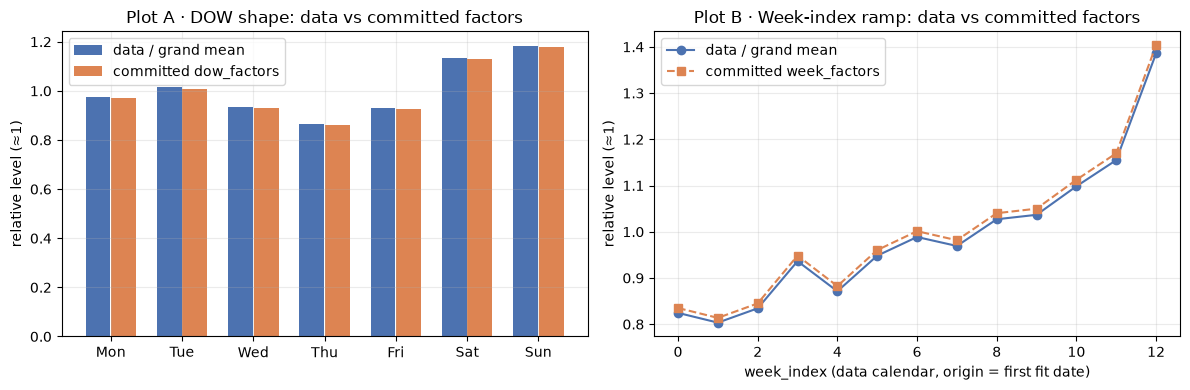

In [2]:
committed_json = json.loads(PROFILE_PATH.read_text())
tol = 1e-5

for key in ("dow_factors", "week_factors"):
    got = refit[key]
    want = committed_json[key]
    assert len(got) == len(want), key
    diffs = [abs(a - b) for a, b in zip(got, want, strict=True)]
    print(f"{key}: max |refit - committed| = {max(diffs):.2e}")
    assert max(diffs) <= tol, f"{key} drift vs committed JSON"

assert abs(refit["scale_target_mu"] - committed_json["scale_target_mu"]) <= tol
assert abs(refit["demand_vm"] - committed_json["demand_vm"]) <= tol
print("✓ Refit matches committed demand_profile.json (bit-for-bit at 1e-5)")

dow_obs = tables.sub.groupby("dow")["sale_amount"].mean()
week_obs = tables.sub.groupby("week_index")["sale_amount"].mean()
grand = float(tables.sub["sale_amount"].mean())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
x = np.arange(7)
axes[0].bar(x - 0.18, dow_obs / grand, width=0.35, label="data / grand mean", color="#4C72B0")
axes[0].bar(
    x + 0.18,
    np.array(refit["dow_factors"]),
    width=0.35,
    label="committed dow_factors",
    color="#DD8452",
)
axes[0].set_xticks(x, DOW_LABELS)
axes[0].set_ylabel("relative level (≈1)")
axes[0].set_title("Plot A · DOW shape: data vs committed factors")
axes[0].legend()

w = np.arange(len(refit["week_factors"]))
axes[1].plot(w, week_obs / grand, "o-", label="data / grand mean", color="#4C72B0")
axes[1].plot(w, refit["week_factors"], "s--", label="committed week_factors", color="#DD8452")
axes[1].set_xlabel("week_index (data calendar, origin = first fit date)")
axes[1].set_ylabel("relative level (≈1)")
axes[1].set_title("Plot B · Week-index ramp: data vs committed factors")
axes[1].legend()
plt.tight_layout()
plt.show()

## 2 · Multiplicative mean model vs DOW×week cells

The fit does **not** estimate a full 7×13 interaction table. Instead each cell mean should
track `grand_mean × dow[d] × week[w]` in **FreshNet sale_amount units** (here `grand_mean ≈ 3.1`).

The committed `scale_target_mu = 30` rescales the same relative shape to operational simulation
units — compare that only in the episode section (Plots H–I), not when auditing the raw fit.


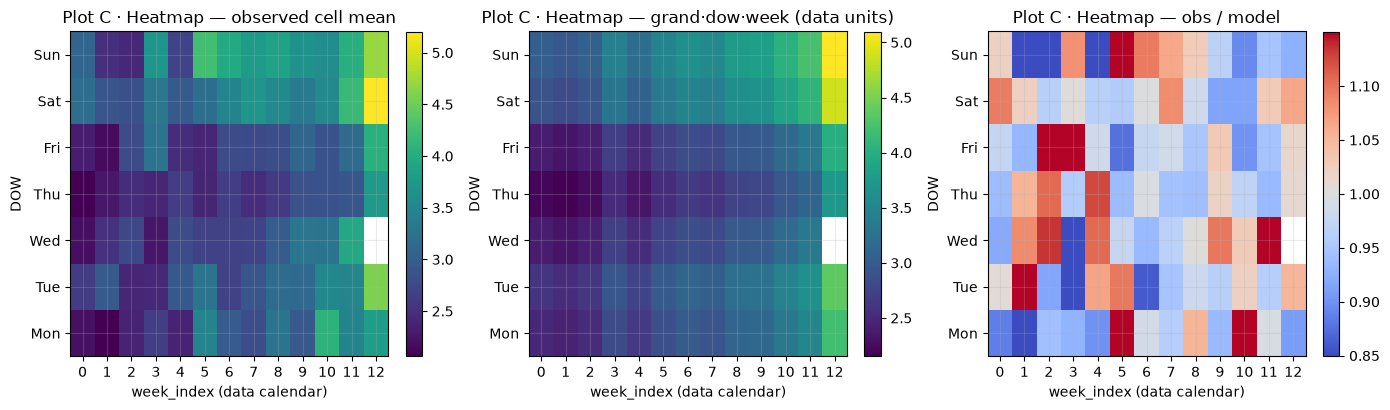

Cell mean RMSE vs multiplicative model: 0.2819 (normalized sale units)
Mean |obs/model − 1|: 0.074


In [3]:
cell = tables.cell.copy()
cell["mu_model"] = cell.apply(lambda r: model_mu_data_units(r, refit, GRAND_MEAN), axis=1)
cell["ratio"] = cell["mean"] / cell["mu_model"]
cell["resid"] = cell["mean"] - cell["mu_model"]

dow_n = len(refit["dow_factors"])
week_n = len(refit["week_factors"])
obs_grid = np.full((dow_n, week_n), np.nan)
pred_grid = np.full((dow_n, week_n), np.nan)
ratio_grid = np.full((dow_n, week_n), np.nan)
for _, r in cell.iterrows():
    d, w = int(r.dow), int(r.week_index)
    obs_grid[d, w] = r["mean"]
    pred_grid[d, w] = r["mu_model"]
    ratio_grid[d, w] = r["ratio"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for ax, grid, title, cmap in [
    (axes[0], obs_grid, "observed cell mean", "viridis"),
    (axes[1], pred_grid, "grand·dow·week (data units)", "viridis"),
    (axes[2], ratio_grid, "obs / model", "coolwarm"),
]:
    norm = TwoSlopeNorm(vmin=0.85, vcenter=1.0, vmax=1.15) if " / " in title else None
    im = ax.imshow(grid, aspect="auto", origin="lower", cmap=cmap, norm=norm)
    ax.set_xticks(range(week_n), [str(i) for i in range(week_n)])
    ax.set_yticks(range(dow_n), DOW_LABELS)
    ax.set_xlabel("week_index (data calendar)")
    ax.set_ylabel("DOW")
    ax.set_title(f"Plot C · Heatmap — {title}")
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

rmse = float(np.sqrt(np.nanmean(cell["resid"] ** 2)))
mape = float(np.nanmean(np.abs(cell["ratio"] - 1.0)))
print(f"Cell mean RMSE vs multiplicative model: {rmse:.4f} (normalized sale units)")
print(f"Mean |obs/model − 1|: {mape:.3f}")


## 3 · Negative binomial layer — several angles

Runtime fixes **`demand_vm = 2`** (variance/mean), not the empirical ~1.1 within-cell V/M
from censored data. We stress-test whether `NB(μ(d), V/M=2)` is a reasonable **second layer**
on top of the multiplicative means.

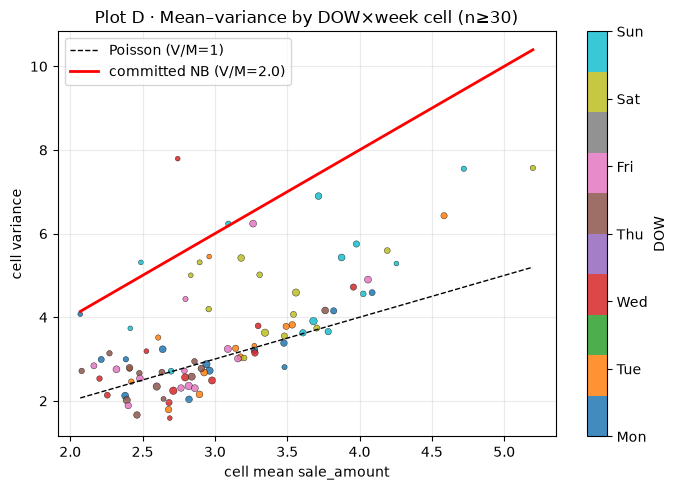

Empirical median within-cell V/M (n≥30): 1.077  (committed vm=2.0)


In [4]:
# Plot D — mean–variance cloud by DOW×week cell
cell_filt = cell[cell["n"] >= 30].copy()
fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(
    cell_filt["mean"],
    cell_filt["var"],
    c=cell_filt["dow"],
    s=np.clip(cell_filt["n"] / 80, 12, 120),
    cmap="tab10",
    alpha=0.85,
    edgecolors="k",
    linewidths=0.3,
)
mu_line = np.linspace(cell_filt["mean"].min(), cell_filt["mean"].max(), 100)
ax.plot(mu_line, mu_line, "k--", lw=1, label="Poisson (V/M=1)")
ax.plot(mu_line, DEMAND_VM * mu_line, "r-", lw=2, label=f"committed NB (V/M={DEMAND_VM})")
ax.set_xlabel("cell mean sale_amount")
ax.set_ylabel("cell variance")
ax.set_title("Plot D · Mean–variance by DOW×week cell (n≥30)")
cb = fig.colorbar(sc, ax=ax, ticks=range(7))
cb.ax.set_yticklabels(DOW_LABELS)
cb.set_label("DOW")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

med_vm = float((cell_filt["var"] / cell_filt["mean"]).median())
print(f"Empirical median within-cell V/M (n≥30): {med_vm:.3f}  (committed vm={DEMAND_VM})")

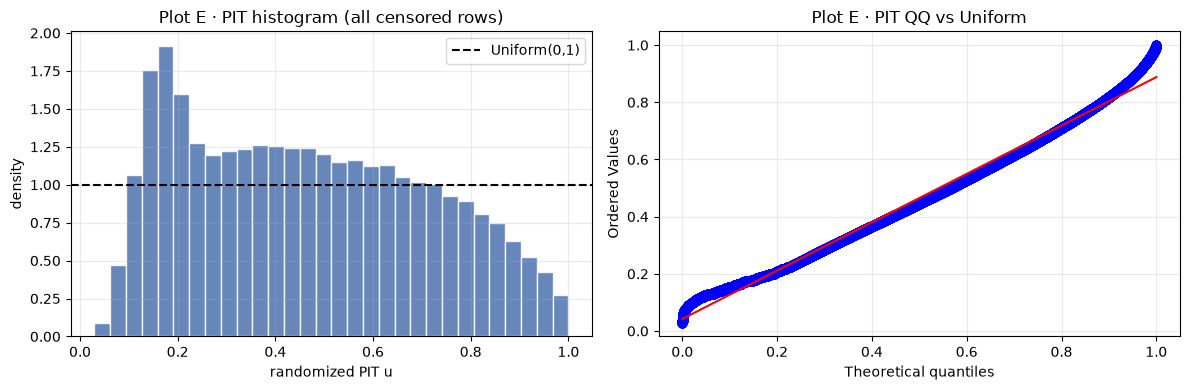

KS vs Uniform: stat=0.0901, p=0.00e+00


In [5]:
# Plot E — randomized PIT uniformity (per-row μ from multiplicative model)
sub = tables.sub.copy()
sub["mu_model"] = sub.apply(lambda r: model_mu_data_units(r, refit, GRAND_MEAN), axis=1)
rng = np.random.default_rng(0)
sub["pit"] = randomized_pit(sub["sale_amount"].to_numpy(), sub["mu_model"].to_numpy(), rng)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(sub["pit"], bins=30, density=True, color="#4C72B0", alpha=0.85, edgecolor="white")
axes[0].axhline(1.0, color="k", ls="--", label="Uniform(0,1)")
axes[0].set_xlabel("randomized PIT u")
axes[0].set_ylabel("density")
axes[0].set_title("Plot E · PIT histogram (all censored rows)")
axes[0].legend()

stats.probplot(sub["pit"], dist="uniform", plot=axes[1])
axes[1].set_title("Plot E · PIT QQ vs Uniform")
plt.tight_layout()
plt.show()

ks = stats.kstest(sub["pit"], "uniform")
print(f"KS vs Uniform: stat={ks.statistic:.4f}, p={ks.pvalue:.2e}")


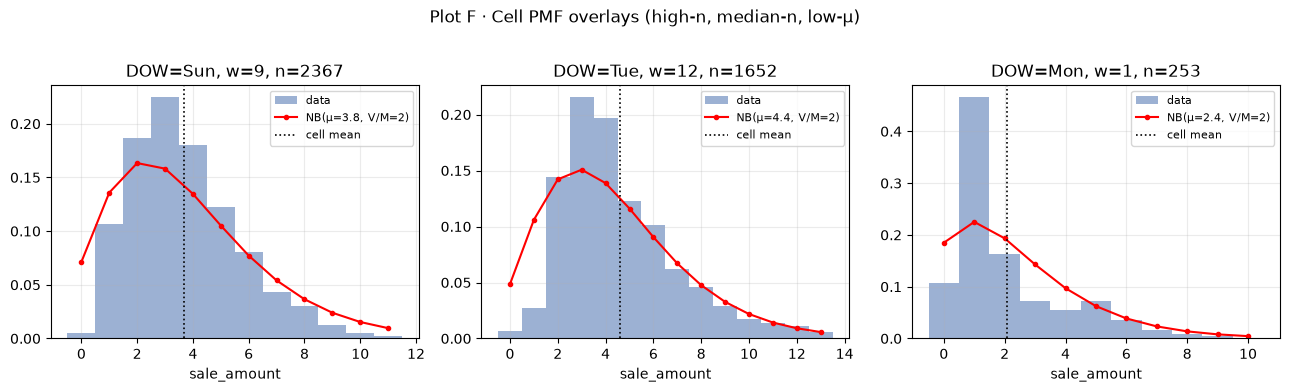

In [6]:
# Plot F — three representative cells: empirical vs NB(μ, vm=2) PMF
cell_sorted = cell.sort_values("n", ascending=False)
examples = [
    cell_sorted.iloc[0],
    cell_sorted.iloc[len(cell_sorted) // 2],
    cell_sorted.query("n >= 30").sort_values("mean").iloc[0],
]

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, row in zip(axes, examples, strict=True):
    mu = float(row["mu_model"])
    r, p = nb_r_p(mu)
    y_max = int(max(row["mean"] * 3, sub["sale_amount"].quantile(0.995)))
    ys = np.arange(0, y_max + 1)
    pmf = stats.nbinom.pmf(ys, r, p)
    mask = (sub["dow"] == row["dow"]) & (sub["week_index"] == row["week_index"])
    obs = sub.loc[mask, "sale_amount"]
    bins = np.arange(-0.5, y_max + 1.5, 1)
    ax.hist(obs, bins=bins, density=True, alpha=0.55, color="#4C72B0", label="data")
    ax.plot(ys, pmf, "r-o", ms=3, label=f"NB(μ={mu:.1f}, V/M=2)")
    ax.axvline(row["mean"], color="k", ls=":", lw=1.2, label="cell mean")
    ax.set_title(
        f"DOW={DOW_LABELS[int(row.dow)]}, w={int(row.week_index)}, n={int(row.n)}"
    )
    ax.set_xlabel("sale_amount")
    ax.legend(fontsize=8)
fig.suptitle("Plot F · Cell PMF overlays (high-n, median-n, low-μ)", y=1.02)
plt.tight_layout()
plt.show()

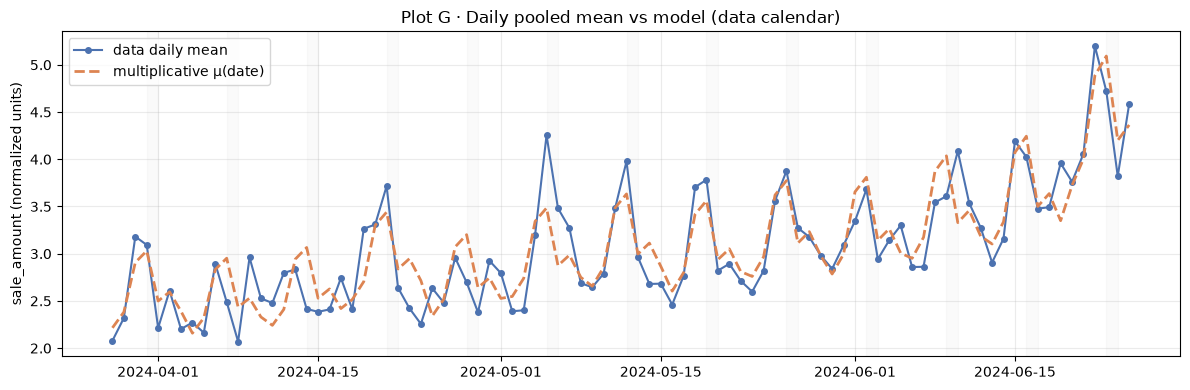

Correlation(obs daily mean, model μ): 0.896


In [7]:
# Plot G — pooled daily means on the data calendar vs model μ(date)
daily = (
    tables.sub.groupby("dt")
    .agg(obs_mean=("sale_amount", "mean"), n=("sale_amount", "size"))
    .reset_index()
)
daily["dow"] = daily["dt"].dt.dayofweek
t0 = tables.sub["dt"].min().normalize()
daily["week_index"] = ((daily["dt"] - t0).dt.days // 7).astype(int)
daily["mu_model"] = daily.apply(lambda r: model_mu_data_units(r, refit, GRAND_MEAN), axis=1)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(daily["dt"], daily["obs_mean"], "o-", ms=4, label="data daily mean", color="#4C72B0")
ax.plot(daily["dt"], daily["mu_model"], "--", lw=2, label="multiplicative μ(date)", color="#DD8452")
for dt in daily["dt"]:
    if dt.dayofweek == 6:
        ax.axvspan(dt, dt + timedelta(days=1), color="grey", alpha=0.04)
ax.set_title("Plot G · Daily pooled mean vs model (data calendar)")
ax.set_ylabel("sale_amount (normalized units)")
ax.legend()
plt.tight_layout()
plt.show()

daily_corr = float(daily["obs_mean"].corr(daily["mu_model"]))
print(f"Correlation(obs daily mean, model μ): {daily_corr:.3f}")


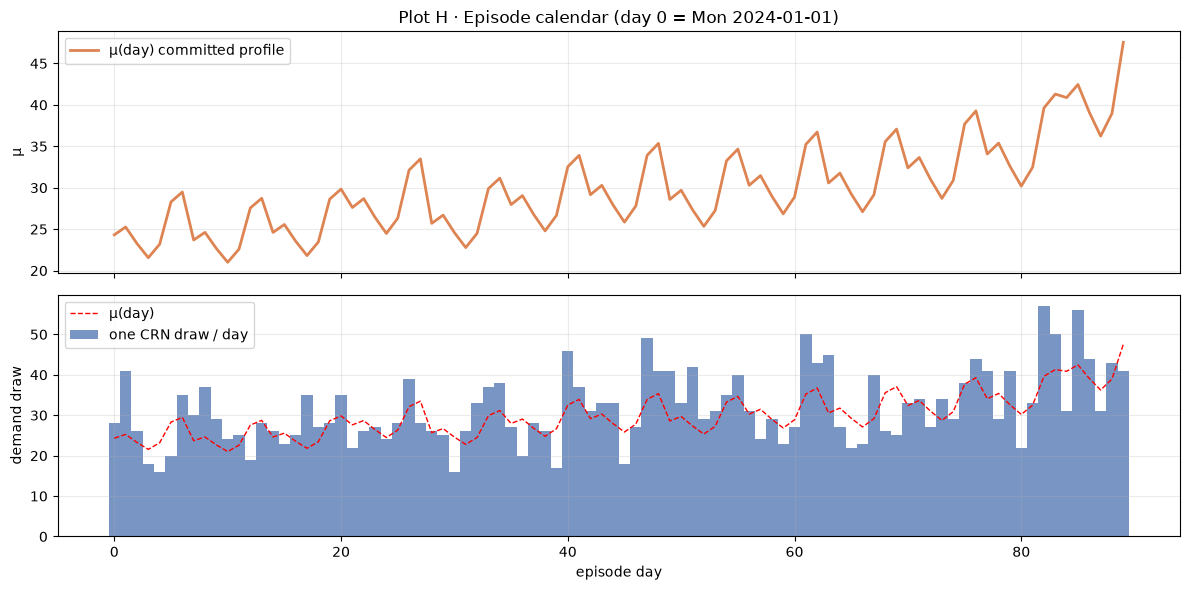

Note: week_factors[0] on the episode axis is week 0 from Jan 1, not FreshNet Mar 28. The ramp shape is borrowed; absolute calendar alignment is not claimed (ADR 0115).


In [8]:
# Plot H — runtime episode axis: μ(day) and simulated draws share CRN addressing
days = np.arange(90)
mu_ep = np.array([committed.mu(int(d)) for d in days])
params = ModelParams(demand_profile=committed, demand_mu=SCALE_MU, demand_vm=DEMAND_VM)
draws = []
for day in days:
    rng = spawn_rng(42, run_id="nb-demo", day=int(day), stream=STREAM_DEMAND)
    draws.append(draw_demand(rng, params, day=int(day)))
draws = np.array(draws)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(days, mu_ep, color="#DD8452", lw=2, label="μ(day) committed profile")
axes[0].set_ylabel("μ")
axes[0].set_title("Plot H · Episode calendar (day 0 = Mon 2024-01-01)")
axes[0].legend()
axes[1].bar(days, draws, color="#4C72B0", alpha=0.75, width=1.0, label="one CRN draw / day")
axes[1].plot(days, mu_ep, "r--", lw=1, label="μ(day)")
axes[1].set_xlabel("episode day")
axes[1].set_ylabel("demand draw")
axes[1].legend()
plt.tight_layout()
plt.show()

print(
    "Note: week_factors[0] on the episode axis is week 0 from Jan 1, not FreshNet Mar 28."
    " The ramp shape is borrowed; absolute calendar alignment is not claimed (ADR 0115)."
)

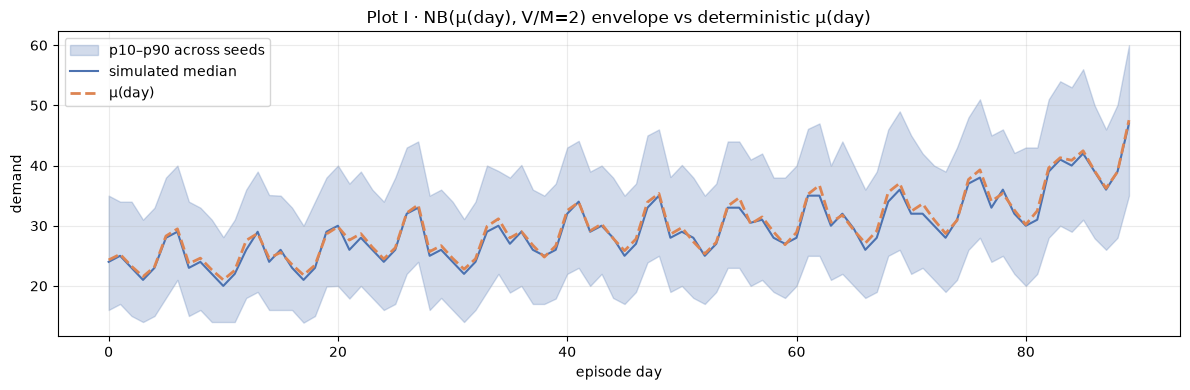

In [9]:
# Plot I — simulation envelope: many CRN seeds vs μ(day) on episode axis
n_seeds = 400
mat = np.zeros((n_seeds, len(days)))
for s in range(n_seeds):
    for day in days:
        rng = spawn_rng(s, run_id="nb-demo", day=int(day), stream=STREAM_DEMAND)
        mat[s, day] = draw_demand(rng, params, day=int(day))
p10, p50, p90 = np.quantile(mat, [0.1, 0.5, 0.9], axis=0)

fig, ax = plt.subplots(figsize=(12, 4))
ax.fill_between(days, p10, p90, color="#4C72B0", alpha=0.25, label="p10–p90 across seeds")
ax.plot(days, p50, color="#4C72B0", lw=1.5, label="simulated median")
ax.plot(days, mu_ep, color="#DD8452", lw=2, ls="--", label="μ(day)")
ax.set_xlabel("episode day")
ax.set_ylabel("demand")
ax.set_title("Plot I · NB(μ(day), V/M=2) envelope vs deterministic μ(day)")
ax.legend()
plt.tight_layout()
plt.show()

## 4 · Which plots are most illustrative?

| Plot | Question it answers | Verdict |
|------|---------------------|---------|
| **A · DOW bars** | Do committed `dow_factors` track pooled weekday levels in censored data? | **Essential** — direct audit of the primary calendar knob viewers touch (weekend lift). |
| **B · Week ramp** | Does the Mar–Jun week-index curve match data? | **Essential** — shows seasonality template extraction; pair with H for episode mapping caveat. |
| **C · Heatmaps** | Where does the multiplicative model miss interaction (DOW×week)? | **High value** — one glance shows structural error budget before blaming NB. |
| **D · Mean–variance** | Is V/M≈2 plausible vs cell clouds? | **High value** — justifies keeping MOD-26 vm even when empirical V/M≈1.1. |
| **E · PIT** | After fixing means, are NB residuals calibrated? | **Diagnostic** — expect KS rejection at huge n; slope/QQ shape still informs. |
| **F · Cell PMFs** | Local shape check for representative cells | **Best for skeptics** — makes discrete NB tangible; pick cells explicitly. |
| **G · Daily time series** | Does the model track day-to-day pooled means? | **Storytelling** — great for blog readers; hides cell-level interaction error. |
| **H · Episode μ + draws** | How injection works at runtime | **Essential for engineers** — links JSON to `draw_demand(..., day=)`. |
| **I · Envelope** | Does stochastic layer sit around μ(day)? | **Nice complement to H** — communicates overdispersion without raw data. |

**Recommended minimum set for a post or review:** **A + B + C + D + H** (data fidelity + error budget + dispersion choice + runtime).

**If space for one figure only:** **C (ratio panel)** — encodes DOW, week, and multiplicative miss in one graphic.

**Caveats to state alongside any figure:**

- `sale_amount` is globally normalized Chinese retail — shape only, scaled to μ≈30.
- Censoring filter (`stock_hour6_22_cnt == 0`) trims stockout-biased days.
- Week factors on the **episode** axis reuse the Mar–Jun ramp template from day 0 (Jan 1), not literal calendar alignment.
- Committed `demand_vm=2` is a **scenario knob**, not the empirical MLE from censored cells.